Dataset Shape: (150, 4)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes: ['setosa' 'versicolor' 'virginica']

=== Basic Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

=== Statistical Summary ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%    

<Figure size 1000x800 with 0 Axes>

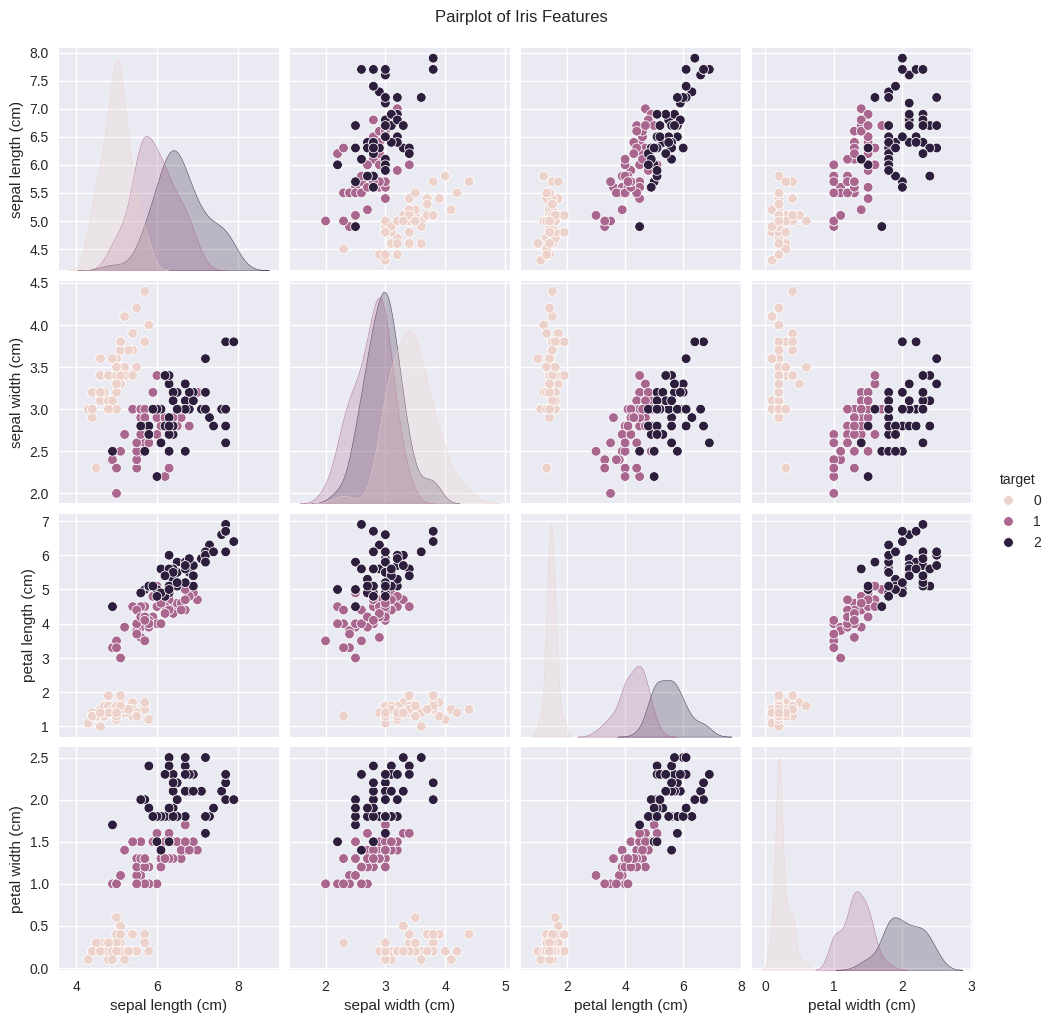

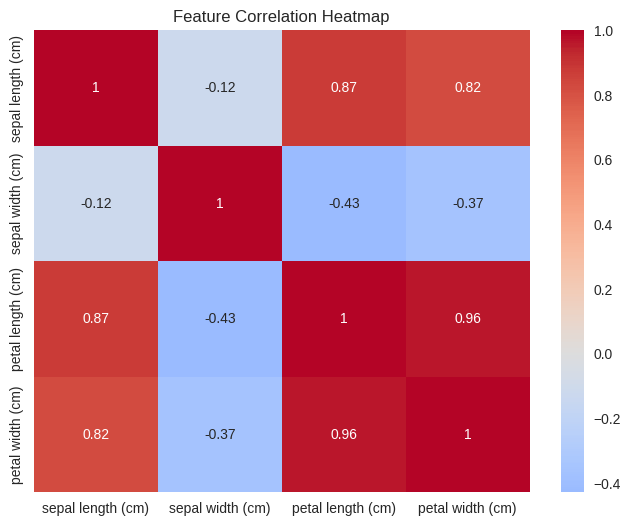

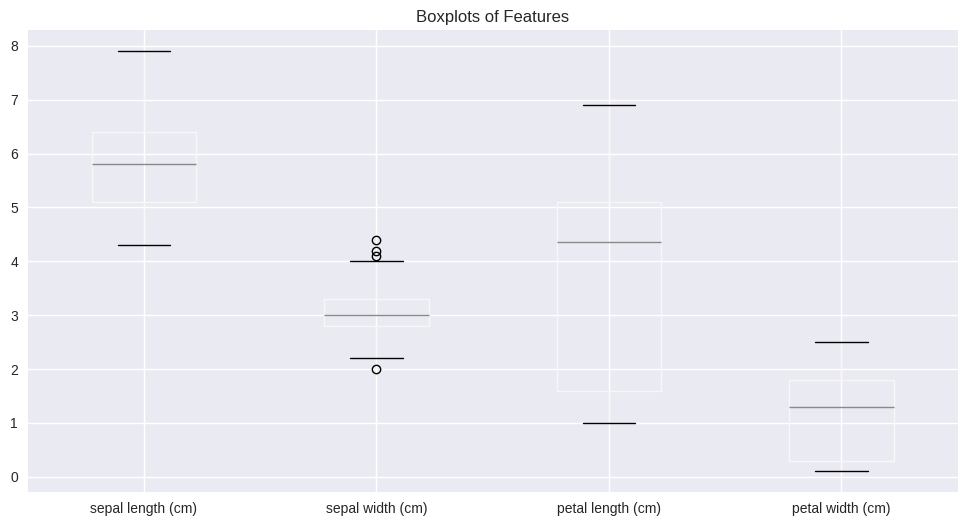

Train shape: (112, 4), Test shape: (38, 4)

=== Default Random Forest Performance ===
Train Accuracy: 1.0
Test Accuracy : 0.9210526315789473

Classification Report (Test):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



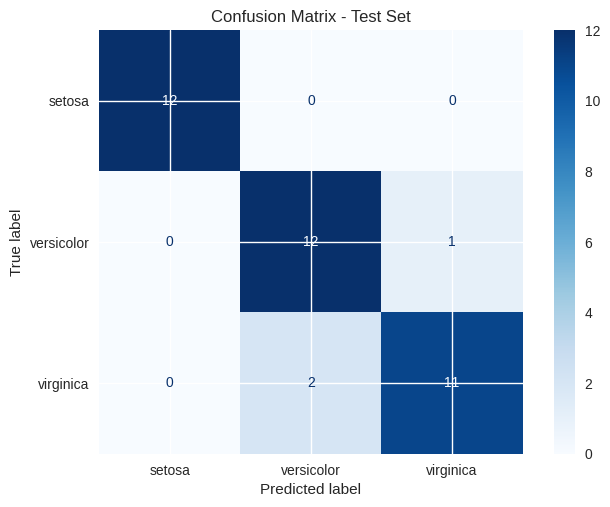


=== Default Hyperparameters ===
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Best Parameters ===
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.9462450592885375

Tuned Model Test Accuracy: 0.9210526315789473


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================
# 1. Load Dataset
# ============================
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset Shape:", X.shape)
print("\nFeature Names:", data.feature_names)
print("Target Classes:", data.target_names)

# ============================
# 2. EDA (Exploratory Data Analysis)
# ============================
print("\n=== Basic Information ===")
print(X.info())
print("\n=== Statistical Summary ===")
print(X.describe())

print("\n=== Target Distribution ===")
print(y.value_counts())

# Pairplot
plt.figure(figsize=(10, 8))
sns.pairplot(pd.concat([X, y], axis=1), hue='target', diag_kind='kde')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# Boxplots to check outliers
plt.figure(figsize=(12, 6))
X.boxplot()
plt.title("Boxplots of Features")
plt.show()

# ============================
# 3. Data Splitting & Scaling (Good Practice)
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Scaling (Random Forest doesn't require it, but it's good practice)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================
# 4. Random Forest Model (Default Parameters)
# ============================
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_default.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = rf_default.predict(X_train_scaled)
y_test_pred = rf_default.predict(X_test_scaled)

# ============================
# 5. Evaluation Metrics
# ============================
print("\n=== Default Random Forest Performance ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=data.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()

# ============================
# 6. Hyperparameters
# ============================
print("\n=== Default Hyperparameters ===")
print(rf_default.get_params())

# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n=== Best Parameters ===")
print(grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

# Evaluate best model
y_test_pred_best = best_rf.predict(X_test_scaled)
print("\nTuned Model Test Accuracy:", accuracy_score(y_test, y_test_pred_best))


Best Model - Train Accuracy: 1.0000
Best Model - Test Accuracy : 0.9211
✅ Good Fit


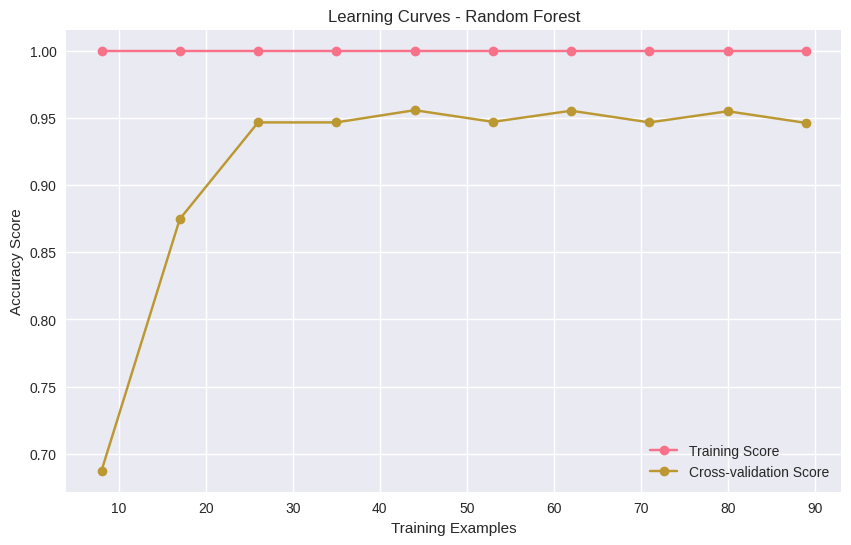

In [2]:
# ============================
# 7. Overfitting / Underfitting Analysis
# ============================
# Train vs Test Score Comparison
train_score = best_rf.score(X_train_scaled, y_train)
test_score = best_rf.score(X_test_scaled, y_test)

print(f"\nBest Model - Train Accuracy: {train_score:.4f}")
print(f"Best Model - Test Accuracy : {test_score:.4f}")

if train_score - test_score > 0.1:
    print("⚠️  Possible Overfitting (Gap is significant)")
elif train_score < 0.7 and test_score < 0.7:
    print("⚠️  Possible Underfitting")
else:
    print("✅ Good Fit")

# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_train_scaled, y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', label='Cross-validation Score')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy Score')
plt.title('Learning Curves - Random Forest')
plt.legend(loc='best')
plt.grid(True)
plt.show()